In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datasets.loader import load_splits
from datasets.paths import ProjectPaths

In [ ]:
paths = ProjectPaths()

In [ ]:
splits = {
	"train": paths.processed_dir,
	"dev": paths.processed_dir,
	"test": paths.processed_dir
}

dfs = load_splits(splits)
df = pd.concat(dfs.values(), ignore_index=True)


In [28]:
df.columns


Index(['sentence1', 'sentence2', 'score', 'split', 'score_norm'], dtype='str')

In [29]:
df["split"].unique()


<StringArray>
['train', 'dev', 'test']
Length: 3, dtype: str

In [30]:
df.describe()


,score,score_norm
count,18039.000000,18039.000000
mean,2.667548,0.533510
std,1.472919,0.294584
min,0.000000,0.000000
25%,1.400000,0.280000
50%,3.000000,0.600000
75%,3.800000,0.760000
max,5.000000,1.000000


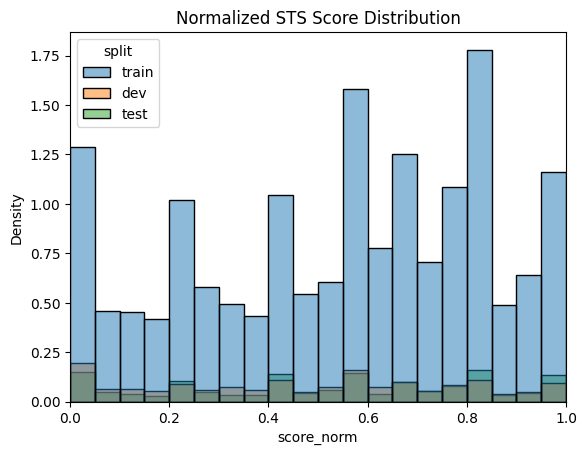

In [31]:
sns.histplot(df, x="score_norm", hue="split", bins=20, stat="density")
plt.title("Normalized STS Score Distribution")
plt.xlim(0,1)
plt.show()


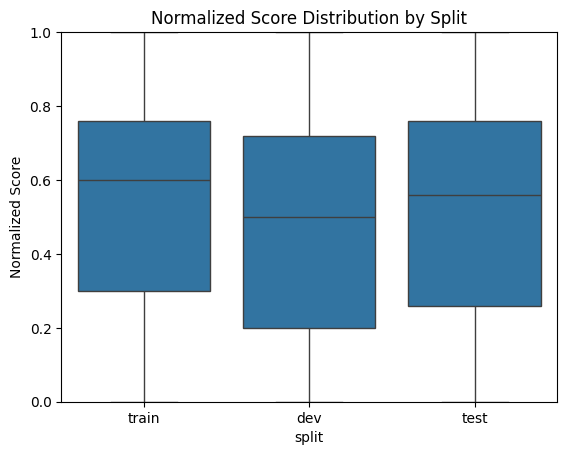

In [32]:
sns.boxplot(data=df, x="split", y="score_norm")

plt.title("Normalized Score Distribution by Split")
plt.ylabel("Normalized Score")
plt.ylim(0, 1)
plt.show()

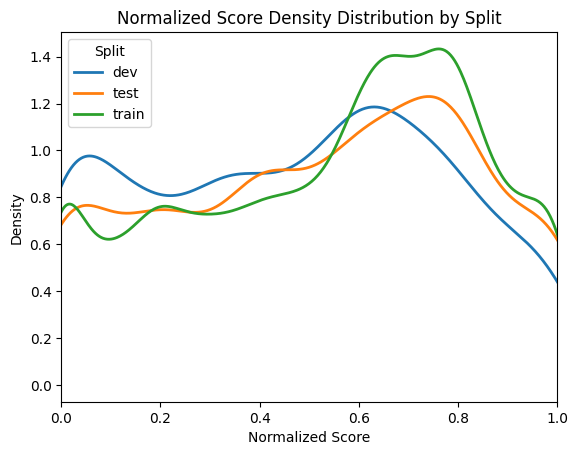

In [33]:
for split, data in df.groupby("split"):
	data["score_norm"].plot(kind="kde", label=split, linewidth=2)

plt.xlabel("Normalized Score")
plt.ylabel("Density")
plt.title("Normalized Score Density Distribution by Split")
plt.xlim(0, 1)
plt.legend(title="Split")
plt.show()

In [34]:
df["len1"] = df["sentence1"].str.split().str.len()
df["len2"] = df["sentence2"].str.split().str.len()

df[["len1", "len2"]].describe()


,len1,len2
count,18039.000000,18039.000000
mean,12.621265,12.567548
std,6.925700,6.776211
min,2.000000,2.000000
25%,8.000000,8.000000
50%,11.000000,11.000000
75%,15.000000,15.000000
max,80.000000,58.000000


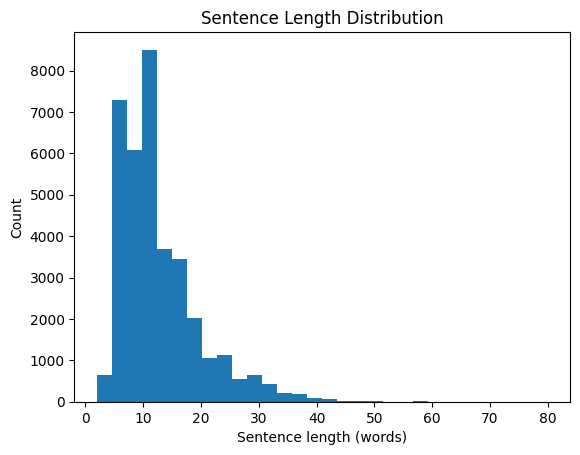

In [35]:
lengths = pd.concat([df["len1"], df["len2"]])

plt.hist(lengths, bins=30)
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()


In [36]:
all_lengths = np.concatenate([df["len1"].values, df["len2"].values])

max_len = int(np.percentile(all_lengths, 95))

print("Suggested 'max_len':", max_len)

truncated = (df["len1"] > max_len).sum() + (df["len2"] > max_len).sum()
total = len(df) * 2

print("Truncation rate:", truncated / total)


Suggested 'max_len': 27
Truncation rate: 0.04662120960141915
